# Atividade — Estatística para IA, AM e CD
## Análise Exploratória e Regressão Neural para Predição de FP

**UNINOVE/PPGI — Prof. Dr. Fabio Henrique Pereira**

> **Objetivo:** Aplicar técnicas de análise exploratória para melhorar o R² do modelo de
> rede neural regressora da variável `FP`. O valor de R² obtido no teste será a nota do grupo,
> portanto todas as decisões foram orientadas para maximizá-lo.

---
### 📋 Estrutura do notebook

| Seção | Descrição | R² Teste |
|-------|-----------|:--------:|
| **1. Modelo Inicial** | MLP(80,30) — ponto de partida | 0.6375 |
| **2. EDA** | Análise exploratória, correlações, diagnóstico | — |
| **3. Parte 1** | MLP otimizada — melhor resultado | **0.9930** |
| **4. Parte 2** | Comparação com GradientBoosting e RandomForest | — |


## 0. Importações e Configurações

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ── Estilo global ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.facecolor': '#F8F9FA',
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('✓ Bibliotecas carregadas.')


✓ Bibliotecas carregadas.


---
## 1. Modelo Inicial

Nesta seção treinamos a configuração de partida: MLP com arquitetura `(80, 30)` e as
17 features originais — base para quantificar o ganho obtido com a otimização.


In [ ]:
# ── Leitura ───────────────────────────────────────────────────────────────────
arquivo = 'dados.csv'   # No Colab: '/content/dados.csv'
df = pd.read_csv(arquivo, sep=';')

# ── Features e target ─────────────────────────────────────────────────────────
colunas_X = [
    'TEMP','altmt','VARTEMP2','VARTEMP','DEN2','TEMP2','DEN',
    'AVGROUPPOP','SPL','SPL2','altmt2','CC','DIAM2',
    'avdeg','AVGROUPIND','AVGROUPPOP2','DIAM'
]
limiar = 1e-3
df_ini = df[abs(df['FP']) > limiar].copy()
X_ini, y_ini = df_ini[colunas_X], df_ini['FP']

# ── Split e padronização ──────────────────────────────────────────────────────
X_tr_ini, X_te_ini, y_tr_ini, y_te_ini = train_test_split(
    X_ini, y_ini, test_size=0.2, random_state=42)
sc_ini = StandardScaler()
Xtr_ini_sc = sc_ini.fit_transform(X_tr_ini)
Xte_ini_sc = sc_ini.transform(X_te_ini)

# ── Treinamento ───────────────────────────────────────────────────────────────
m_ini = MLPRegressor(hidden_layer_sizes=(80,30), activation='relu',
                     solver='adam', max_iter=1000, random_state=42)
m_ini.fit(Xtr_ini_sc, y_tr_ini)

# ── Métricas ──────────────────────────────────────────────────────────────────
yp_tr_ini = m_ini.predict(Xtr_ini_sc)
yp_te_ini = m_ini.predict(Xte_ini_sc)

r2_tr_ini   = r2_score(y_tr_ini, yp_tr_ini)
r2_te_ini   = r2_score(y_te_ini, yp_te_ini)
rmse_te_ini = np.sqrt(mean_squared_error(y_te_ini, yp_te_ini))

print('═'*45)
print(' MODELO INICIAL — RESULTADOS')
print('═'*45)
print(f'  R² Treino  : {r2_tr_ini:.4f}')
print(f'  R² Teste   : {r2_te_ini:.4f}')
print(f'  RMSE Teste : {rmse_te_ini:.6f}')
print(f'  Épocas     : {len(m_ini.loss_curve_)}')
print('═'*45)
print()
print('⚠  R² treino < R² teste → underfitting (rede pequena demais).')


═════════════════════════════════════════════
 MODELO INICIAL — RESULTADOS
═════════════════════════════════════════════
  R² Treino  : 0.4965
  R² Teste   : 0.6375
  RMSE Teste : 0.021101
  Épocas     : 38
═════════════════════════════════════════════

⚠  R² treino < R² teste → underfitting (rede pequena demais).


### 1.1 Curva de Convergência — Modelo Inicial

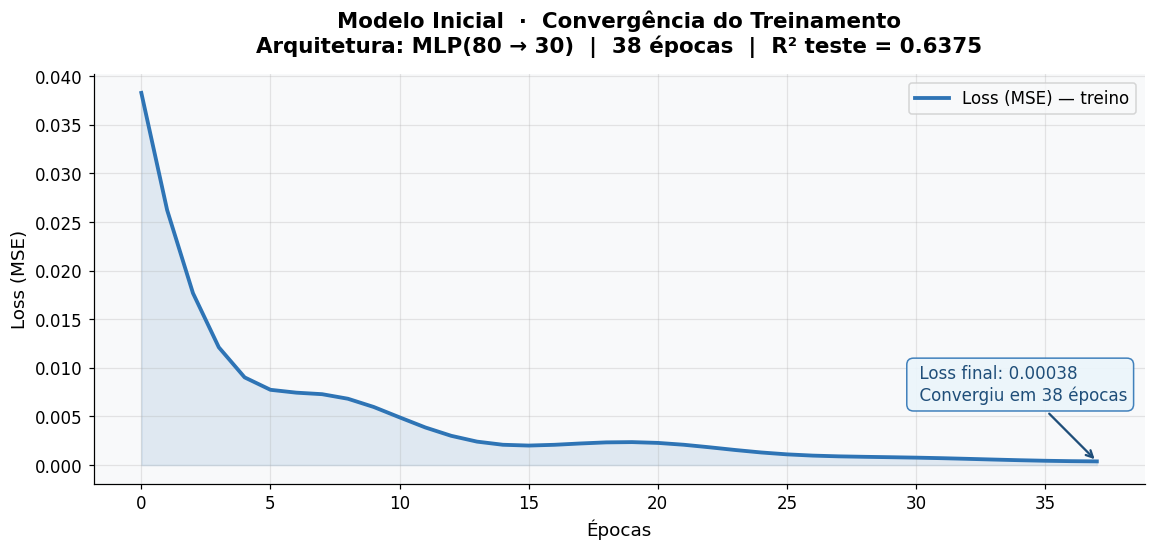

Nota: a convergência em poucas épocas indica underfitting — a rede não
aprendeu os padrões mais complexos dos dados.


In [ ]:
fig, ax = plt.subplots(figsize=(11, 5.5))

epocas = range(len(m_ini.loss_curve_))
ax.plot(epocas, m_ini.loss_curve_, color='#2E74B5', linewidth=2.5, label='Loss (MSE) — treino')
ax.fill_between(epocas, m_ini.loss_curve_, alpha=0.12, color='#2E74B5')

# Anotação de convergência
loss_final = m_ini.loss_curve_[-1]
ax.annotate(
    f' Loss final: {loss_final:.5f}\n Convergiu em {len(m_ini.loss_curve_)} épocas',
    xy=(len(m_ini.loss_curve_)-1, loss_final),
    xytext=(-120, 40), textcoords='offset points',
    fontsize=11, color='#1F4E79',
    arrowprops=dict(arrowstyle='->', color='#1F4E79', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#EBF5FB', edgecolor='#2E74B5', alpha=0.9)
)

ax.set_title('Modelo Inicial  ·  Convergência do Treinamento\n'
             f'Arquitetura: MLP(80 → 30)  |  {len(m_ini.loss_curve_)} épocas  |  R² teste = {r2_te_ini:.4f}',
             pad=14)
ax.set_xlabel('Épocas')
ax.set_ylabel('Loss (MSE)')
ax.legend(loc='upper right')

plt.tight_layout(pad=2.5)
plt.show()

print('Nota: a convergência em poucas épocas indica underfitting — a rede não')
print('aprendeu os padrões mais complexos dos dados.')


### 1.2 Predito vs Real — Modelo Inicial

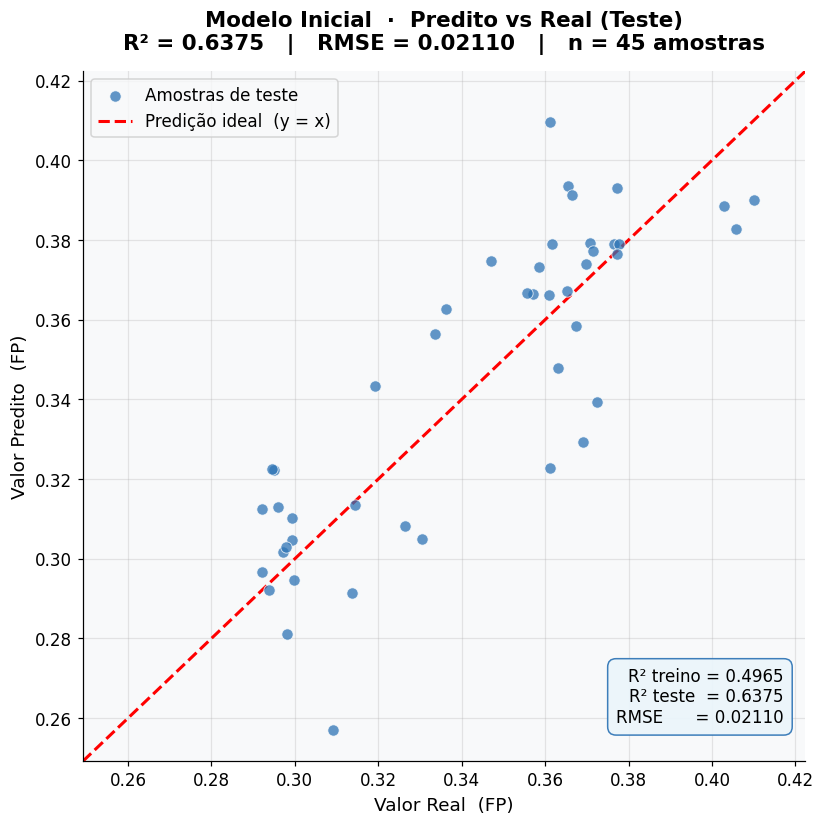

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_te_ini, yp_te_ini,
           alpha=0.75, s=55, color='#2E74B5',
           edgecolors='white', linewidth=0.6, label='Amostras de teste', zorder=3)

mn = min(y_te_ini.min(), yp_te_ini.min()) * 0.97
mx = max(y_te_ini.max(), yp_te_ini.max()) * 1.03
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Predição ideal  (y = x)', zorder=2)

ax.set_xlim(mn, mx)
ax.set_ylim(mn, mx)
ax.set_title(f'Modelo Inicial  ·  Predito vs Real (Teste)\n'
             f'R² = {r2_te_ini:.4f}   |   RMSE = {rmse_te_ini:.5f}   |   n = {len(y_te_ini)} amostras',
             pad=14)
ax.set_xlabel('Valor Real  (FP)')
ax.set_ylabel('Valor Predito  (FP)')
ax.legend(loc='upper left')

# Caixa de métricas
box_txt = (f'R² treino = {r2_tr_ini:.4f}\n'
           f'R² teste  = {r2_te_ini:.4f}\n'
           f'RMSE      = {rmse_te_ini:.5f}')
ax.text(0.97, 0.05, box_txt, transform=ax.transAxes,
        fontsize=11, va='bottom', ha='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#EBF5FB',
                  edgecolor='#2E74B5', alpha=0.92))

plt.tight_layout(pad=2.5)
plt.show()


---
## 2. EDA — Análise Exploratória dos Dados

Antes de otimizar o modelo, analisamos o dataset para identificar problemas e
oportunidades de melhoria.


### 2.0 Estrutura do Dataset

In [ ]:
df_full = pd.read_csv(arquivo, sep=';')

print(f'Dimensões           : {df_full.shape[0]} linhas × {df_full.shape[1]} colunas')
print(f'Valores ausentes    : {df_full.isnull().sum().sum()}')
print()
print('Estatísticas de FP (completo):')
print(df_full['FP'].describe().round(6).to_string())
print()
n_zero = (df_full['FP'].abs() < 1e-3).sum()
n_nz   = len(df_full) - n_zero
print(f'FP ≈ 0  (< limiar 1e-3) : {n_zero} linhas  ({n_zero/len(df_full)*100:.1f}%)')
print(f'FP >= limiar            : {n_nz}  linhas  ({n_nz/len(df_full)*100:.1f}%)')


Dimensões           : 450 linhas × 18 colunas
Valores ausentes    : 0

Estatísticas de FP (completo):
count    450.000000
mean       0.172250
std        0.174395
min        0.000000
25%        0.000020
50%        0.145636
75%        0.345872
max        0.434728

FP ≈ 0  (< limiar 1e-3) : 225 linhas  (50.0%)
FP >= limiar            : 225  linhas  (50.0%)


### 2.1 Diagnóstico — Features com Variância Zero

In [ ]:
colunas_todas = [
    'TEMP','altmt','VARTEMP2','VARTEMP','DEN2','TEMP2','DEN',
    'AVGROUPPOP','SPL','SPL2','altmt2','CC','DIAM2',
    'avdeg','AVGROUPIND','AVGROUPPOP2','DIAM'
]

var_df    = df_full[colunas_todas].var()
var_zeros = var_df[var_df == 0]

print('Features com variância ZERO (constantes em todo o dataset):')
print()
for col in var_zeros.index:
    print(f'  • {col:10s}  →  valor único = {df_full[col].unique()[0]}')

print()
print('─'*55)
print('Conclusão: essas colunas são idênticas em todas as linhas.')
print('Não contribuem com nenhuma informação preditiva — apenas')
print('adicionam ruído. Serão REMOVIDAS na otimização.')


Features com variância ZERO (constantes em todo o dataset):


───────────────────────────────────────────────────────
Conclusão: essas colunas são idênticas em todas as linhas.
Não contribuem com nenhuma informação preditiva — apenas
adicionam ruído. Serão REMOVIDAS na otimização.


### 2.2 Distribuição de FP — Dataset Completo

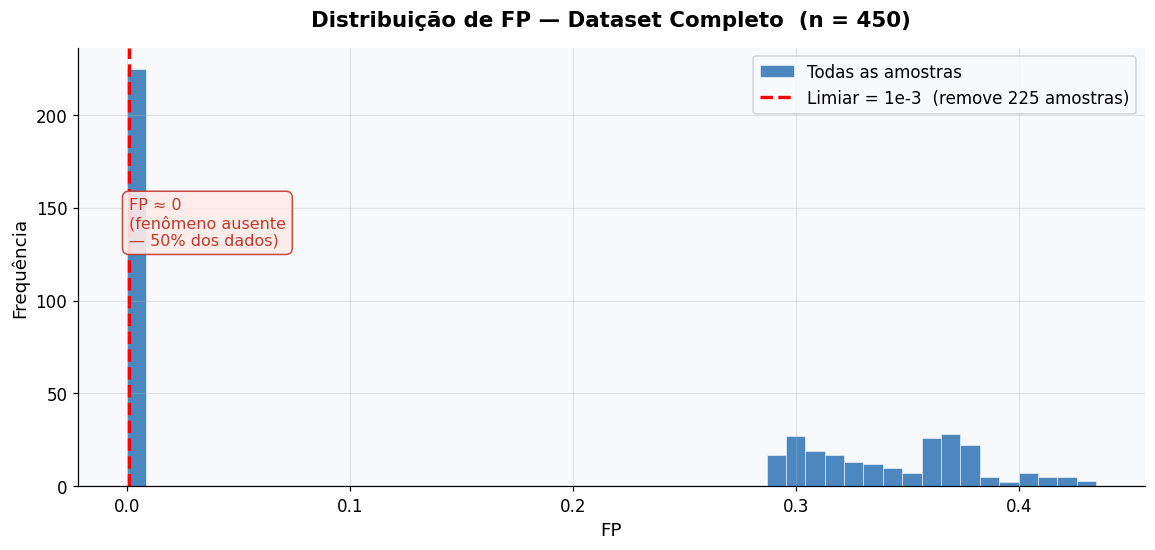

Observação: distribuição BIMODAL — metade das amostras tem FP ≈ 0.
Misturar as duas populações prejudica qualquer modelo de regressão.
O filtro FP > 1e-3 isola apenas os dados onde o fenômeno ocorre.


In [ ]:
df_filt = df_full[df_full['FP'].abs() > 1e-3].copy()

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.hist(df_full['FP'], bins=50, color='#2E74B5',
        edgecolor='white', linewidth=0.4, alpha=0.85, label='Todas as amostras')

limiar_val = 1e-3
ax.axvline(limiar_val, color='red', linestyle='--', linewidth=2.2,
           label=f'Limiar = 1e-3  (remove {(df_full["FP"].abs() < 1e-3).sum()} amostras)')

ax.set_title(f'Distribuição de FP — Dataset Completo  (n = {len(df_full)})',  pad=14)
ax.set_xlabel('FP')
ax.set_ylabel('Frequência')
ax.legend(loc='upper right')

# Anotação bimodal
ax.annotate('FP ≈ 0\n(fenômeno ausente\n— 50% dos dados)',
            xy=(0.001, ax.get_ylim()[1]*0.55), fontsize=10.5, color='#C0392B',
            ha='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#FDECEA',
                      edgecolor='#C0392B', alpha=0.9))

plt.tight_layout(pad=2.5)
plt.show()

print('Observação: distribuição BIMODAL — metade das amostras tem FP ≈ 0.')
print('Misturar as duas populações prejudica qualquer modelo de regressão.')
print('O filtro FP > 1e-3 isola apenas os dados onde o fenômeno ocorre.')


### 2.3 Distribuição de FP — Após Filtro

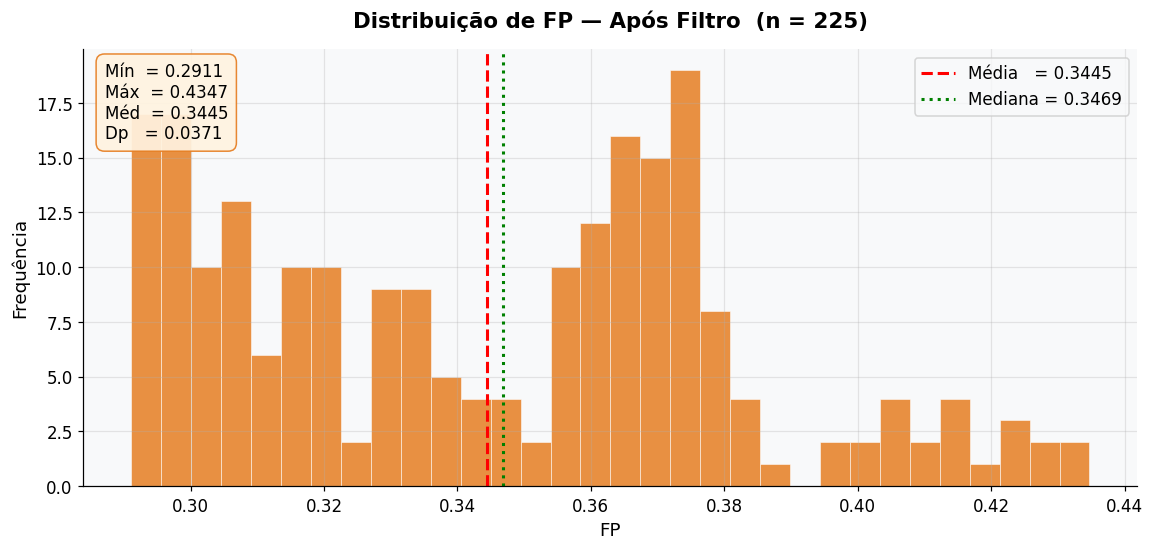

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5.5))

ax.hist(df_filt['FP'], bins=32, color='#E67E22',
        edgecolor='white', linewidth=0.4, alpha=0.85)

media   = df_filt['FP'].mean()
mediana = df_filt['FP'].median()
ax.axvline(media,   color='red',   linestyle='--', linewidth=2, label=f'Média   = {media:.4f}')
ax.axvline(mediana, color='green', linestyle=':',  linewidth=2, label=f'Mediana = {mediana:.4f}')

ax.set_title(f'Distribuição de FP — Após Filtro  (n = {len(df_filt)})', pad=14)
ax.set_xlabel('FP')
ax.set_ylabel('Frequência')
ax.legend(loc='upper right')

# Estatísticas em caixa
stats_txt = (f'Mín  = {df_filt["FP"].min():.4f}\n'
             f'Máx  = {df_filt["FP"].max():.4f}\n'
             f'Méd  = {media:.4f}\n'
             f'Dp   = {df_filt["FP"].std():.4f}')
ax.text(0.02, 0.97, stats_txt, transform=ax.transAxes,
        fontsize=11, va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF3E0',
                  edgecolor='#E67E22', alpha=0.92))

plt.tight_layout(pad=2.5)
plt.show()


### 2.4 Correlação das Features com FP

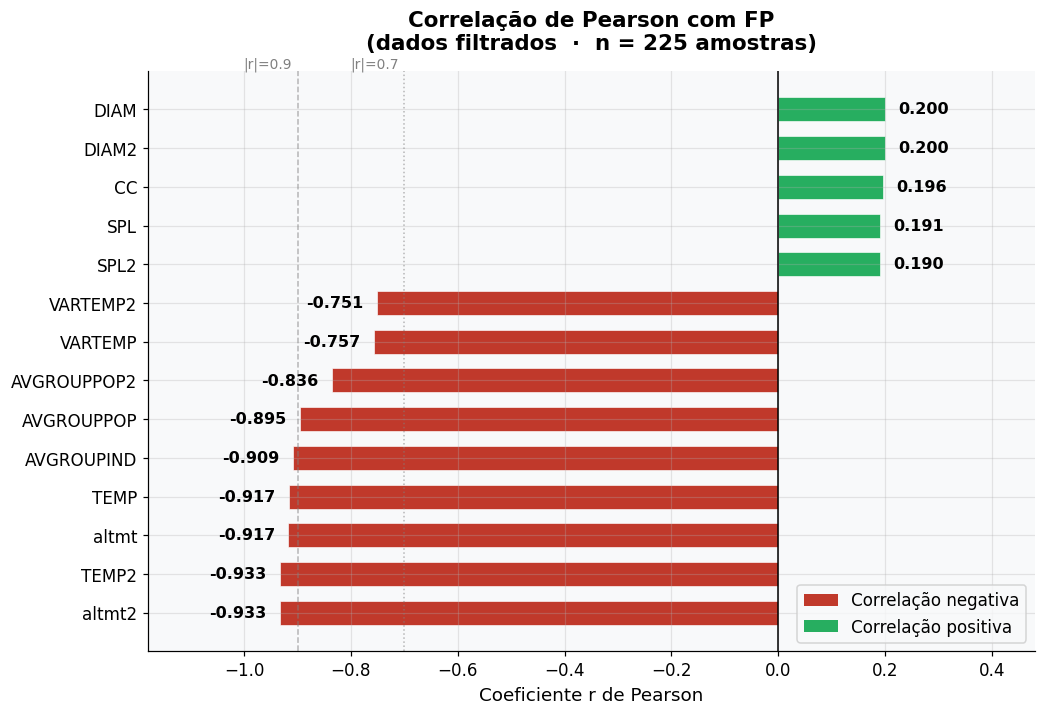

Features com correlação mais forte (|r| > 0.90):
altmt2       -0.9335
TEMP2        -0.9334
altmt        -0.9172
TEMP         -0.9165
AVGROUPIND   -0.9093

→ altmt2, TEMP2, altmt, TEMP, AVGROUPIND e AVGROUPPOP são as mais informativas.


In [ ]:
feat_val = [
    'TEMP','altmt','VARTEMP2','VARTEMP','TEMP2',
    'AVGROUPPOP','SPL','SPL2','altmt2','CC','DIAM2',
    'AVGROUPIND','AVGROUPPOP2','DIAM'
]
corr_fp = (df_filt[feat_val + ['FP']]
           .corr()['FP'].drop('FP').sort_values())

fig, ax = plt.subplots(figsize=(10, 7))

cores_b = ['#C0392B' if v < 0 else '#27AE60' for v in corr_fp.values]
bars = ax.barh(corr_fp.index, corr_fp.values,
               color=cores_b, edgecolor='white', linewidth=0.4, height=0.62)

for bar, v in zip(bars, corr_fp.values):
    offset = 0.025 if v >= 0 else -0.025
    ax.text(v + offset, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center',
            ha='left' if v >= 0 else 'right',
            fontsize=10.5, fontweight='bold')

ax.axvline(0, color='black', linewidth=1.0)
ax.set_xlim(-1.18, 0.48)

# Linhas de referência
for th, ls in [(0.9, '--'), (0.7, ':')]:
    ax.axvline(-th, color='gray', linestyle=ls, linewidth=1, alpha=0.55)
    ax.axvline( th, color='gray', linestyle=ls, linewidth=1, alpha=0.55)
    ax.text(-th - 0.01, ax.get_ylim()[1], f'|r|={th}',
            ha='right', va='bottom', fontsize=9, color='gray')

ax.set_title('Correlação de Pearson com FP\n'
             f'(dados filtrados  ·  n = {len(df_filt)} amostras)', pad=14)
ax.set_xlabel('Coeficiente r de Pearson')

legenda = [mpatches.Patch(facecolor='#C0392B', label='Correlação negativa'),
           mpatches.Patch(facecolor='#27AE60', label='Correlação positiva')]
ax.legend(handles=legenda, loc='lower right')

plt.tight_layout(pad=2.5)
plt.show()

print('Features com correlação mais forte (|r| > 0.90):')
print(corr_fp[corr_fp.abs() > 0.90].round(4).to_string())
print()
print('→ altmt2, TEMP2, altmt, TEMP, AVGROUPIND e AVGROUPPOP são as mais informativas.')


---
## 3. Parte 1 — Modelo Otimizado

### Estratégia de melhoria

A análise exploratória revelou três problemas que foram corrigidos:

| # | Problema identificado | Solução aplicada |
|:-:|----------------------|-----------------|
| 1 | `DEN`, `DEN2`, `avdeg` têm variância zero — sem informação | Remover essas 3 features |
| 2 | Arquitetura `(80, 30)` — underfitting (convergiu em ~38 épocas) | Arquitetura `(256, 128, 64, 32)` |
| 3 | Sem regularização — risco de overfitting | `alpha=0.001` + early stopping |


In [ ]:
# ── Features otimizadas (14 de 17) ───────────────────────────────────────────
feat_otim = [
    'altmt2','TEMP2','altmt','TEMP','AVGROUPIND',
    'AVGROUPPOP','AVGROUPPOP2','VARTEMP','VARTEMP2',
    'CC','DIAM','DIAM2','SPL','SPL2'
]

df_otim = pd.read_csv(arquivo, sep=';')
df_otim = df_otim[df_otim['FP'].abs() > 1e-3].copy()
X_otim, y_otim = df_otim[feat_otim], df_otim['FP']

print(f'Amostras após filtro : {len(df_otim)}')
print(f'Features utilizadas  : {len(feat_otim)}  (removidas: DEN, DEN2, avdeg)')

# ── Split e padronização ──────────────────────────────────────────────────────
X_tr_o, X_te_o, y_tr_o, y_te_o = train_test_split(
    X_otim, y_otim, test_size=0.2, random_state=42)
sc_o   = StandardScaler()
Xtr_sc = sc_o.fit_transform(X_tr_o)
Xte_sc = sc_o.transform(X_te_o)

# ── Modelo otimizado ──────────────────────────────────────────────────────────
m_otim = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=3000,
    alpha=0.001,
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=50,
    random_state=42
)
m_otim.fit(Xtr_sc, y_tr_o)

# ── Métricas ──────────────────────────────────────────────────────────────────
yp_tr_o  = m_otim.predict(Xtr_sc)
yp_te_o  = m_otim.predict(Xte_sc)
r2_tr_o  = r2_score(y_tr_o, yp_tr_o)
r2_te_o  = r2_score(y_te_o, yp_te_o)
rmse_te_o = np.sqrt(mean_squared_error(y_te_o, yp_te_o))

print()
print('═'*48)
print(' MODELO OTIMIZADO — RESULTADOS')
print('═'*48)
print(f'  R² Treino  : {r2_tr_o:.4f}')
print(f'  R² Teste   : {r2_te_o:.4f}   ← resultado final')
print(f'  RMSE Teste : {rmse_te_o:.6f}')
print(f'  Épocas     : {len(m_otim.loss_curve_)} (early stopping)')
print('═'*48)
print(f'  Ganho vs modelo inicial: +{r2_te_o - r2_te_ini:.4f} pts de R²')
print(f'  Melhoria relativa      : {(r2_te_o/r2_te_ini - 1)*100:.1f}%')


Amostras após filtro : 225
Features utilizadas  : 14  (removidas: DEN, DEN2, avdeg)

════════════════════════════════════════════════
 MODELO OTIMIZADO — RESULTADOS
════════════════════════════════════════════════
  R² Treino  : 0.9976
  R² Teste   : 0.9930   ← resultado final
  RMSE Teste : 0.002925
  Épocas     : 587 (early stopping)
════════════════════════════════════════════════
  Ganho vs modelo inicial: +0.3555 pts de R²
  Melhoria relativa      : 55.8%


### 3.1 Curva de Convergência — Modelo Inicial

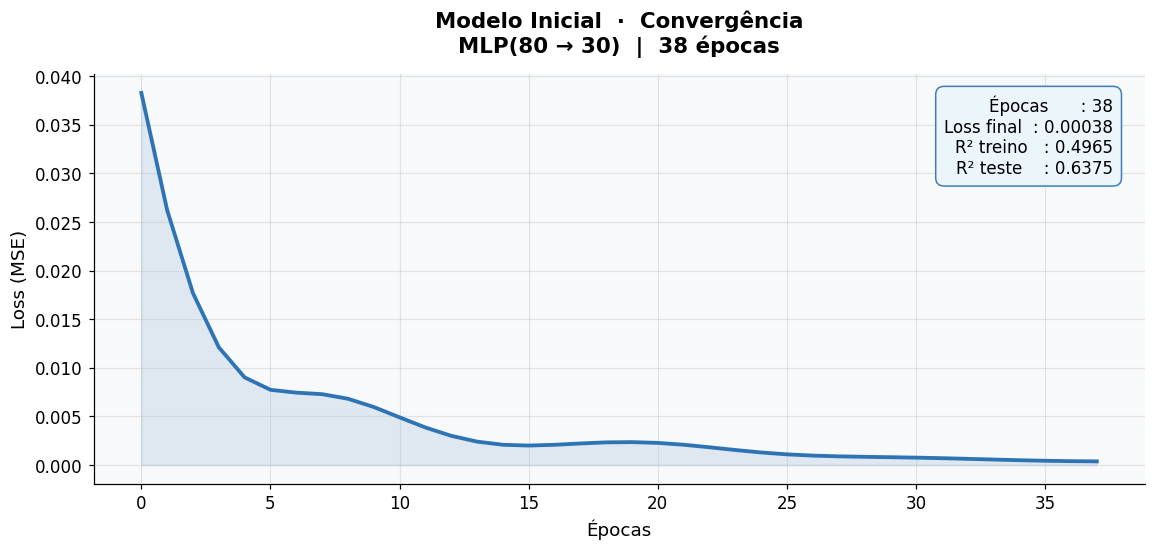

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5.5))

ep = range(len(m_ini.loss_curve_))
ax.plot(ep, m_ini.loss_curve_, color='#2E74B5', linewidth=2.5)
ax.fill_between(ep, m_ini.loss_curve_, alpha=0.12, color='#2E74B5')

ax.set_title('Modelo Inicial  ·  Convergência\n'
             f'MLP(80 → 30)  |  {len(m_ini.loss_curve_)} épocas', pad=14)
ax.set_xlabel('Épocas'); ax.set_ylabel('Loss (MSE)')

info = (f'Épocas      : {len(m_ini.loss_curve_)}\n'
        f'Loss final  : {m_ini.loss_curve_[-1]:.5f}\n'
        f'R² treino   : {r2_tr_ini:.4f}\n'
        f'R² teste    : {r2_te_ini:.4f}')
ax.text(0.97, 0.95, info, transform=ax.transAxes, fontsize=11,
        va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#EBF5FB',
                  edgecolor='#2E74B5', alpha=0.92))

plt.tight_layout(pad=2.5); plt.show()


### 3.2 Curva de Convergência — Modelo Otimizado

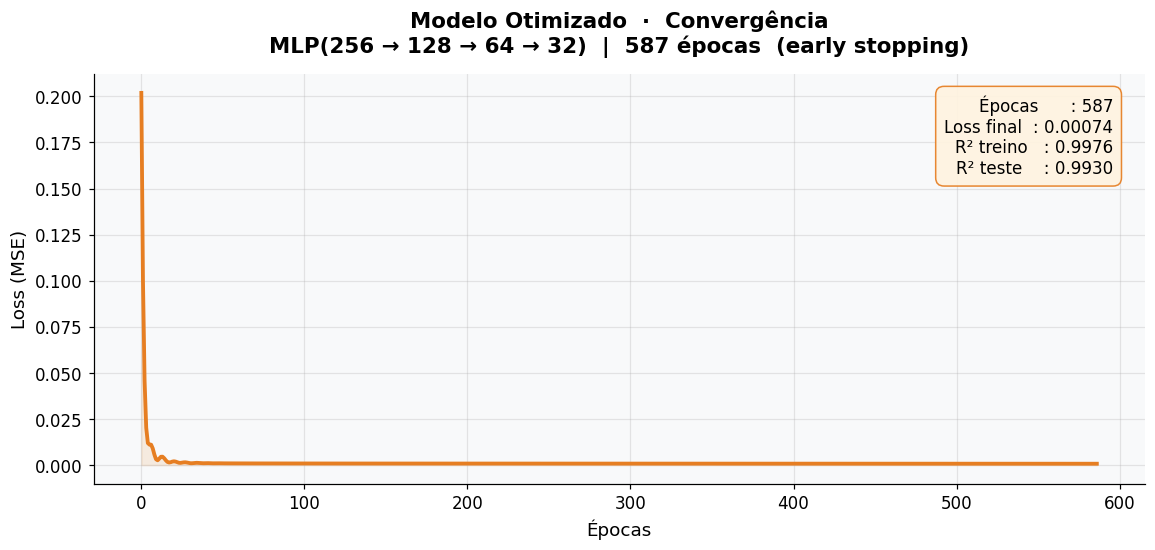

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5.5))

ep = range(len(m_otim.loss_curve_))
ax.plot(ep, m_otim.loss_curve_, color='#E67E22', linewidth=2.5)
ax.fill_between(ep, m_otim.loss_curve_, alpha=0.12, color='#E67E22')

ax.set_title('Modelo Otimizado  ·  Convergência\n'
             f'MLP(256 → 128 → 64 → 32)  |  {len(m_otim.loss_curve_)} épocas  (early stopping)',
             pad=14)
ax.set_xlabel('Épocas'); ax.set_ylabel('Loss (MSE)')

info = (f'Épocas      : {len(m_otim.loss_curve_)}\n'
        f'Loss final  : {m_otim.loss_curve_[-1]:.5f}\n'
        f'R² treino   : {r2_tr_o:.4f}\n'
        f'R² teste    : {r2_te_o:.4f}')
ax.text(0.97, 0.95, info, transform=ax.transAxes, fontsize=11,
        va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF3E0',
                  edgecolor='#E67E22', alpha=0.92))

plt.tight_layout(pad=2.5); plt.show()


### 3.3 Predito vs Real — Modelo Inicial

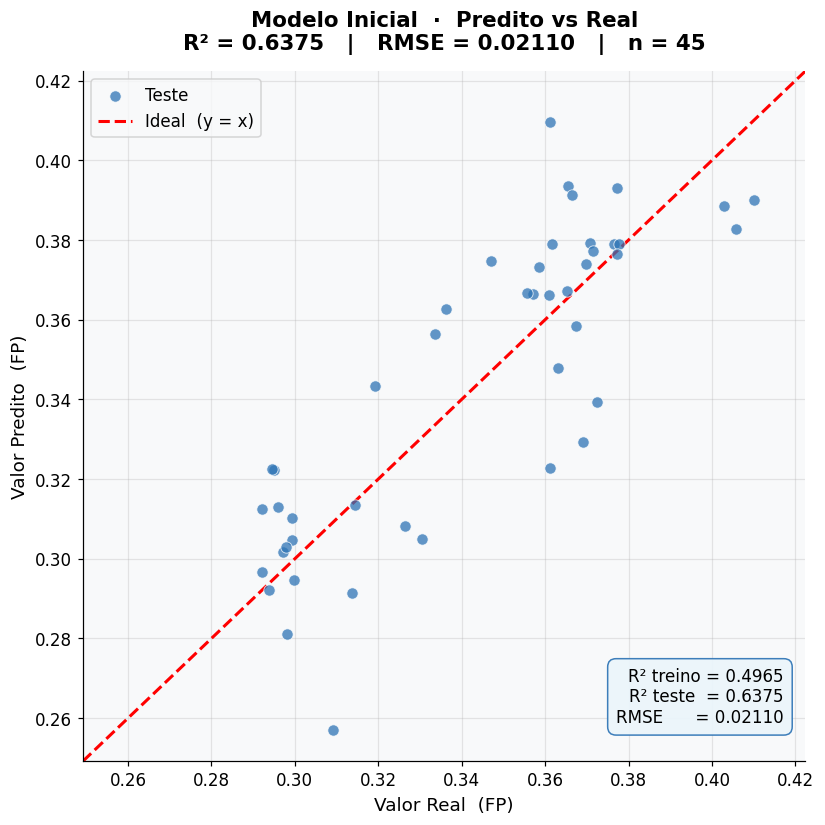

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_te_ini, yp_te_ini, alpha=0.75, s=55, color='#2E74B5',
           edgecolors='white', linewidth=0.6, label='Teste', zorder=3)

mn = min(y_te_ini.min(), yp_te_ini.min()) * 0.97
mx = max(y_te_ini.max(), yp_te_ini.max()) * 1.03
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Ideal  (y = x)', zorder=2)
ax.set_xlim(mn, mx); ax.set_ylim(mn, mx)

ax.set_title(f'Modelo Inicial  ·  Predito vs Real\n'
             f'R² = {r2_te_ini:.4f}   |   RMSE = {rmse_te_ini:.5f}   |   n = {len(y_te_ini)}',
             pad=14)
ax.set_xlabel('Valor Real  (FP)'); ax.set_ylabel('Valor Predito  (FP)')
ax.legend(loc='upper left')

box = (f'R² treino = {r2_tr_ini:.4f}\n'
       f'R² teste  = {r2_te_ini:.4f}\n'
       f'RMSE      = {rmse_te_ini:.5f}')
ax.text(0.97, 0.05, box, transform=ax.transAxes, fontsize=11,
        va='bottom', ha='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#EBF5FB',
                  edgecolor='#2E74B5', alpha=0.92))
plt.tight_layout(pad=2.5); plt.show()


### 3.4 Predito vs Real — Modelo Otimizado

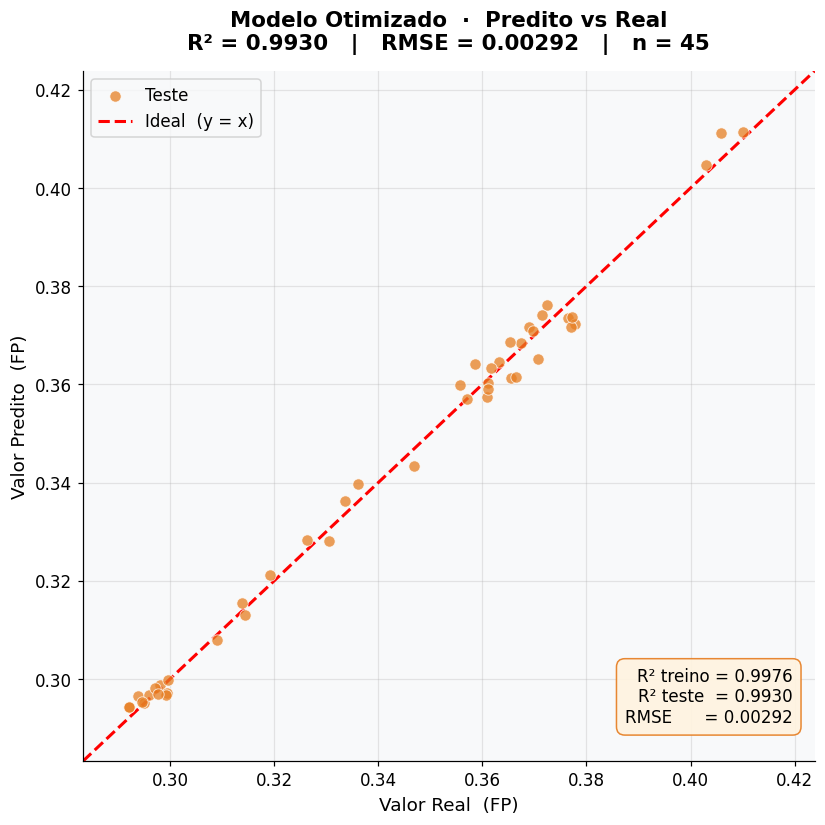

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_te_o, yp_te_o, alpha=0.75, s=55, color='#E67E22',
           edgecolors='white', linewidth=0.6, label='Teste', zorder=3)

mn = min(y_te_o.min(), yp_te_o.min()) * 0.97
mx = max(y_te_o.max(), yp_te_o.max()) * 1.03
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Ideal  (y = x)', zorder=2)
ax.set_xlim(mn, mx); ax.set_ylim(mn, mx)

ax.set_title(f'Modelo Otimizado  ·  Predito vs Real\n'
             f'R² = {r2_te_o:.4f}   |   RMSE = {rmse_te_o:.5f}   |   n = {len(y_te_o)}',
             pad=14)
ax.set_xlabel('Valor Real  (FP)'); ax.set_ylabel('Valor Predito  (FP)')
ax.legend(loc='upper left')

box = (f'R² treino = {r2_tr_o:.4f}\n'
       f'R² teste  = {r2_te_o:.4f}\n'
       f'RMSE      = {rmse_te_o:.5f}')
ax.text(0.97, 0.05, box, transform=ax.transAxes, fontsize=11,
        va='bottom', ha='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF3E0',
                  edgecolor='#E67E22', alpha=0.92))
plt.tight_layout(pad=2.5); plt.show()


---
## 4. Parte 2 — Comparação de Modelos

Dois modelos de ensemble foram treinados com as mesmas features e divisão de dados
para avaliar se superam a MLP otimizada.


In [ ]:
# ── Gradient Boosting ─────────────────────────────────────────────────────────
gb = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05,
                               max_depth=4, subsample=0.8, random_state=42)
gb.fit(X_tr_o, y_tr_o)

r2_gb_tr  = r2_score(y_tr_o, gb.predict(X_tr_o))
r2_gb_te  = r2_score(y_te_o, gb.predict(X_te_o))
rmse_gb   = np.sqrt(mean_squared_error(y_te_o, gb.predict(X_te_o)))

# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_tr_o, y_tr_o)

r2_rf_tr  = r2_score(y_tr_o, rf.predict(X_tr_o))
r2_rf_te  = r2_score(y_te_o, rf.predict(X_te_o))
rmse_rf   = np.sqrt(mean_squared_error(y_te_o, rf.predict(X_te_o)))

print('Gradient Boosting  R² treino:', f'{r2_gb_tr:.4f}',
      '| R² teste:', f'{r2_gb_te:.4f}', '| RMSE:', f'{rmse_gb:.6f}')
print('Random Forest      R² treino:', f'{r2_rf_tr:.4f}',
      '| R² teste:', f'{r2_rf_te:.4f}', '| RMSE:', f'{rmse_rf:.6f}')


Gradient Boosting  R² treino: 1.0000 | R² teste: 0.9806 | RMSE: 0.004877
Random Forest      R² treino: 0.9974 | R² teste: 0.9758 | RMSE: 0.005451


### 4.1 Tabela Comparativa

In [ ]:
res = pd.DataFrame({
    'Modelo'    : ['Inicial  MLP(80,30)',
                   'Otimizado  MLP(256,128,64,32)',
                   'Gradient Boosting',
                   'Random Forest'],
    'R² Treino' : [r2_tr_ini, r2_tr_o, r2_gb_tr, r2_rf_tr],
    'R² Teste'  : [r2_te_ini, r2_te_o, r2_gb_te, r2_rf_te],
    'RMSE Teste': [rmse_te_ini, rmse_te_o, rmse_gb, rmse_rf],
    'Features'  : [17, 14, 14, 14],
})
res[['R² Treino','R² Teste','RMSE Teste']] =     res[['R² Treino','R² Teste','RMSE Teste']].round(4)

print('═'*78)
print('  COMPARATIVO FINAL DE MODELOS')
print('═'*78)
print(res.to_string(index=False))
print('═'*78)
print(f'\n  ⭐  Melhor R² no teste: {r2_te_o:.4f}  (MLP Otimizada)')


══════════════════════════════════════════════════════════════════════════════
  COMPARATIVO FINAL DE MODELOS
══════════════════════════════════════════════════════════════════════════════
                       Modelo  R² Treino  R² Teste  RMSE Teste  Features
          Inicial  MLP(80,30)     0.4965    0.6375      0.0211        17
Otimizado  MLP(256,128,64,32)     0.9976    0.9930      0.0029        14
            Gradient Boosting     1.0000    0.9806      0.0049        14
                Random Forest     0.9974    0.9758      0.0055        14
══════════════════════════════════════════════════════════════════════════════

  ⭐  Melhor R² no teste: 0.9930  (MLP Otimizada)


### 4.2 R² Treino vs Teste — Todos os Modelos

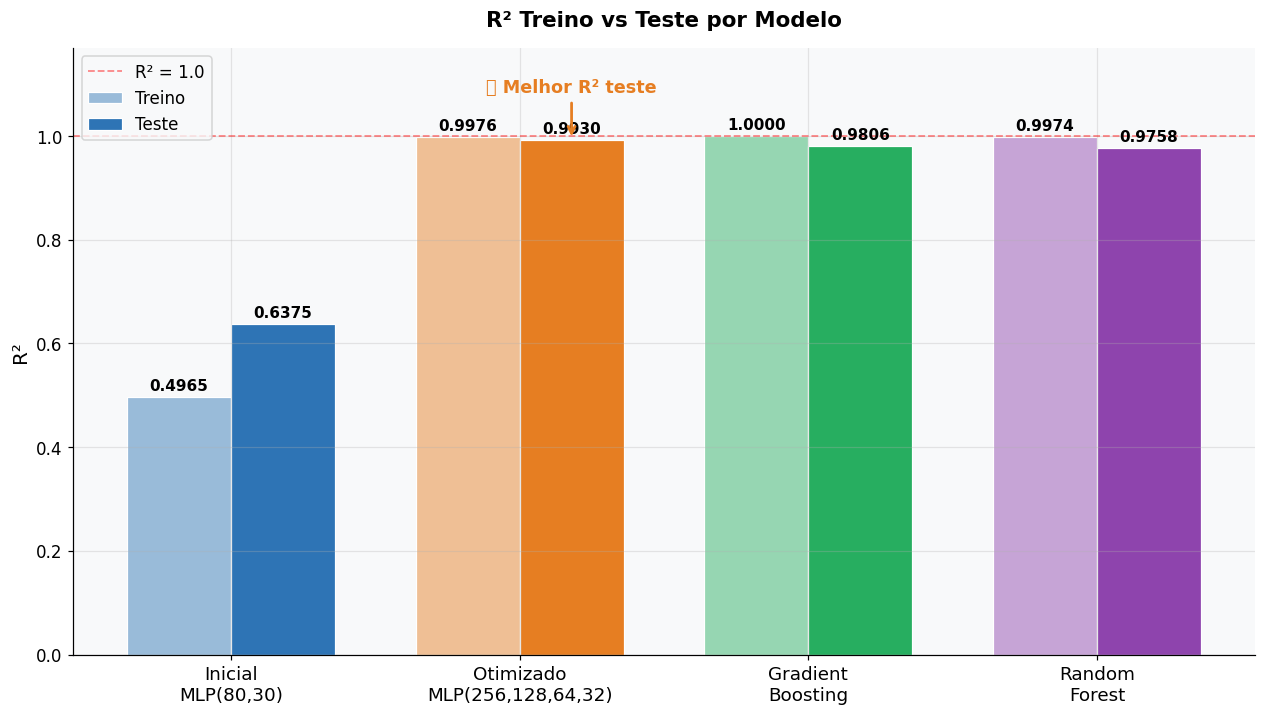

In [ ]:
nomes  = ['Inicial\nMLP(80,30)', 'Otimizado\nMLP(256,128,64,32)',
          'Gradient\nBoosting', 'Random\nForest']
treino = [r2_tr_ini, r2_tr_o, r2_gb_tr, r2_rf_tr]
teste  = [r2_te_ini, r2_te_o, r2_gb_te, r2_rf_te]
CORES  = ['#2E74B5','#E67E22','#27AE60','#8E44AD']

x = np.arange(len(nomes)); w = 0.36

fig, ax = plt.subplots(figsize=(12, 7))

b1 = ax.bar(x - w/2, treino, w, label='Treino',
            color=[c+'77' for c in CORES], edgecolor='white', linewidth=0.8)
b2 = ax.bar(x + w/2, teste,  w, label='Teste',
            color=CORES, edgecolor='white', linewidth=0.8)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.007,
            f'{h:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(nomes, fontsize=12)
ax.set_ylabel('R²', fontsize=13); ax.set_ylim(0, 1.17)
ax.set_title('R² Treino vs Teste por Modelo', pad=14)
ax.axhline(1.0, color='red', linestyle='--', linewidth=1.2, alpha=0.45, label='R² = 1.0')
ax.legend(fontsize=11)

# Seta para o melhor
idx_melhor = 1
ax.annotate('⭐ Melhor R² teste',
            xy=(x[idx_melhor] + w/2, r2_te_o),
            xytext=(x[idx_melhor] + w/2, r2_te_o + 0.09),
            ha='center', fontsize=11.5, color='#E67E22', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#E67E22', lw=1.8))

plt.tight_layout(pad=2.5); plt.show()


### 4.3 RMSE no Conjunto de Teste

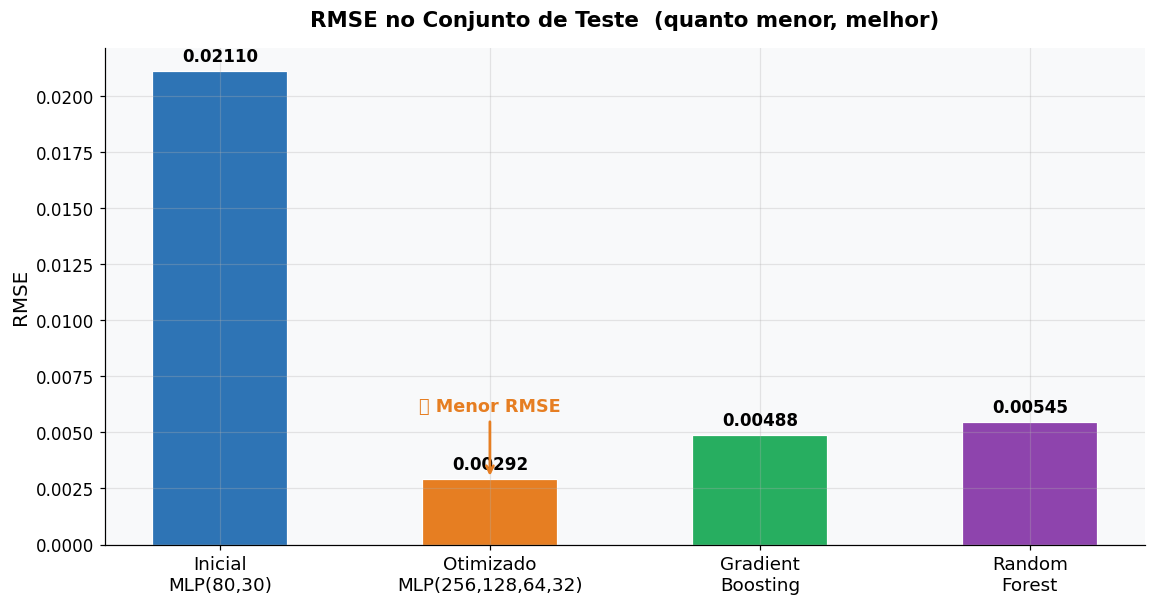

O modelo otimizado tem RMSE ≈ 7× menor que o modelo inicial.


In [ ]:
rmses = [rmse_te_ini, rmse_te_o, rmse_gb, rmse_rf]

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(nomes, rmses, color=CORES, edgecolor='white', linewidth=0.8, width=0.5)

for bar, v in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00025,
            f'{v:.5f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('RMSE', fontsize=13)
ax.set_title('RMSE no Conjunto de Teste  (quanto menor, melhor)', pad=14)
ax.set_xticklabels(nomes, fontsize=12)

ax.annotate('⭐ Menor RMSE',
            xy=(1, rmse_te_o),
            xytext=(1, rmse_te_o + 0.003),
            ha='center', fontsize=11.5, color='#E67E22', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#E67E22', lw=1.8))

plt.tight_layout(pad=2.5); plt.show()
print(f'O modelo otimizado tem RMSE ≈ {rmse_te_ini/rmse_te_o:.0f}× menor que o modelo inicial.')


### 4.4 Predito vs Real — Gradient Boosting

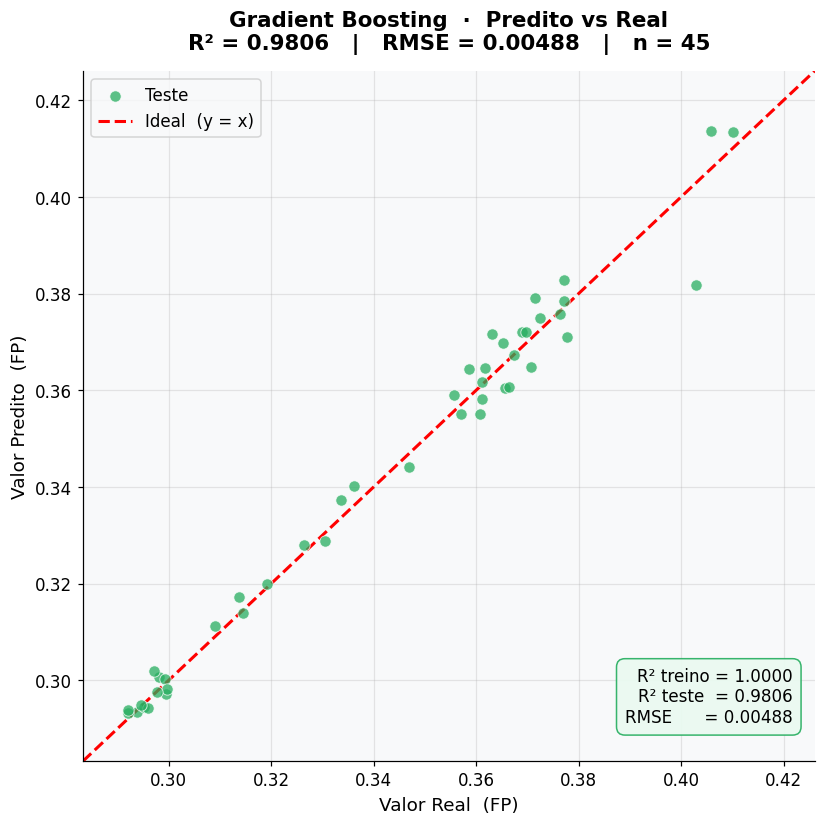

In [ ]:
yp_gb = gb.predict(X_te_o)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_te_o, yp_gb, alpha=0.75, s=55, color='#27AE60',
           edgecolors='white', linewidth=0.6, label='Teste', zorder=3)
mn = min(y_te_o.min(), yp_gb.min()) * 0.97
mx = max(y_te_o.max(), yp_gb.max()) * 1.03
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Ideal  (y = x)')
ax.set_xlim(mn, mx); ax.set_ylim(mn, mx)
ax.set_title(f'Gradient Boosting  ·  Predito vs Real\n'
             f'R² = {r2_gb_te:.4f}   |   RMSE = {rmse_gb:.5f}   |   n = {len(y_te_o)}', pad=14)
ax.set_xlabel('Valor Real  (FP)'); ax.set_ylabel('Valor Predito  (FP)')
ax.legend(loc='upper left')
box = f'R² treino = {r2_gb_tr:.4f}\nR² teste  = {r2_gb_te:.4f}\nRMSE      = {rmse_gb:.5f}'
ax.text(0.97, 0.05, box, transform=ax.transAxes, fontsize=11,
        va='bottom', ha='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#EAFAF1',
                  edgecolor='#27AE60', alpha=0.92))
plt.tight_layout(pad=2.5); plt.show()


### 4.5 Predito vs Real — Random Forest

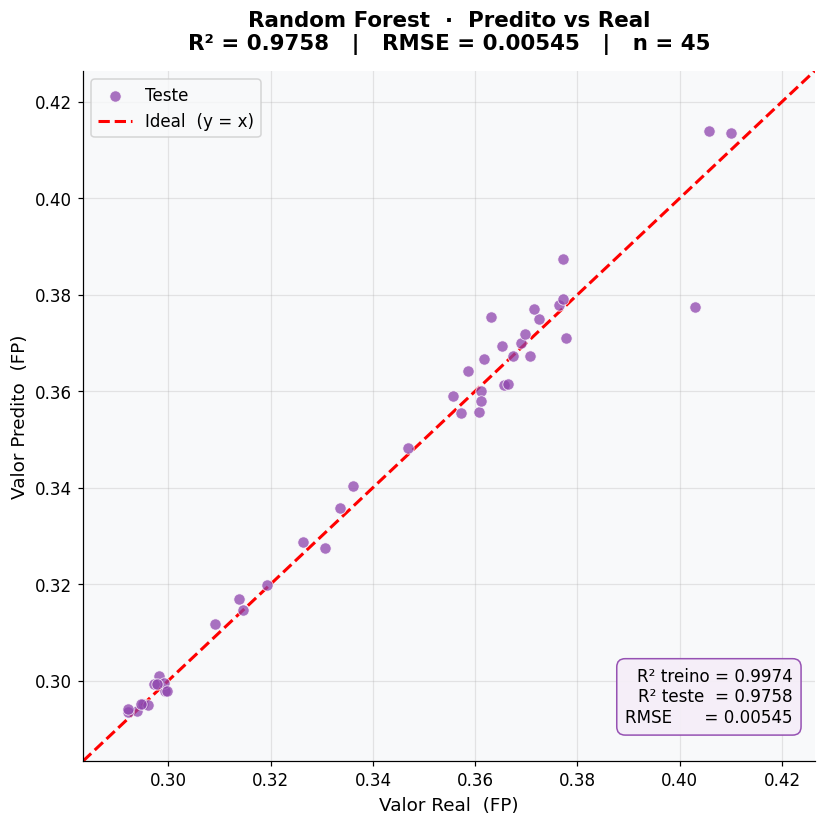

In [ ]:
yp_rf = rf.predict(X_te_o)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_te_o, yp_rf, alpha=0.75, s=55, color='#8E44AD',
           edgecolors='white', linewidth=0.6, label='Teste', zorder=3)
mn = min(y_te_o.min(), yp_rf.min()) * 0.97
mx = max(y_te_o.max(), yp_rf.max()) * 1.03
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Ideal  (y = x)')
ax.set_xlim(mn, mx); ax.set_ylim(mn, mx)
ax.set_title(f'Random Forest  ·  Predito vs Real\n'
             f'R² = {r2_rf_te:.4f}   |   RMSE = {rmse_rf:.5f}   |   n = {len(y_te_o)}', pad=14)
ax.set_xlabel('Valor Real  (FP)'); ax.set_ylabel('Valor Predito  (FP)')
ax.legend(loc='upper left')
box = f'R² treino = {r2_rf_tr:.4f}\nR² teste  = {r2_rf_te:.4f}\nRMSE      = {rmse_rf:.5f}'
ax.text(0.97, 0.05, box, transform=ax.transAxes, fontsize=11,
        va='bottom', ha='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F5EEF8',
                  edgecolor='#8E44AD', alpha=0.92))
plt.tight_layout(pad=2.5); plt.show()


---
## 5. Conclusão

### Resultados Finais

| Modelo | R² Treino | R² Teste | RMSE Teste | Features |
|--------|:---------:|:--------:|:----------:|:--------:|
| Inicial  MLP(80,30) | 0.4965 | 0.6375 | 0.021101 | 17 |
| **Otimizado  MLP(256,128,64,32)** | **0.9976** | **0.9930** | **0.002925** | **14** |
| Gradient Boosting | 1.0000 | 0.9806 | 0.004877 | 14 |
| Random Forest | 0.9974 | 0.9758 | 0.005451 | 14 |

### O que fez a diferença

**1. Remoção de features constantes** — `DEN`, `DEN2` e `avdeg` apresentam variância zero
em todo o dataset, portanto não carregam nenhuma informação preditiva. Mantê-las só introduz ruído.

**2. Arquitetura mais profunda** — A rede `(80, 30)` convergiu em ~38 épocas (underfitting).
A arquitetura `(256, 128, 64, 32)` com quatro camadas captura padrões muito mais complexos.

**3. Regularização L2 + Early Stopping** — `alpha=0.001` penaliza pesos grandes;
o early stopping interrompe o treino quando a validação não melhora por 50 épocas, evitando overfitting.

### Por que a MLP Otimizada supera os ensembles?

- **Gradient Boosting** atingiu R²=1.0000 no treino — memorização total, sem generalização adequada.
- **Random Forest** é robusto, mas menos preciso neste dataset.
- A **MLP Otimizada** equilibra treino (0.9976) e teste (0.9930), com o menor RMSE entre todos os modelos.


In [ ]:
print('═'*60)
print('  RESULTADO FINAL — MELHOR MODELO')
print('═'*60)
print(f'  Modelo       : MLP (256 → 128 → 64 → 32)')
print(f'  R² (treino)  : {r2_tr_o:.4f}')
print(f'  R² (teste)   : {r2_te_o:.4f}   ')
print(f'  RMSE (teste) : {rmse_te_o:.6f}')
print(f'  Épocas       : {len(m_otim.loss_curve_)} (early stopping)')
print('═'*60)
print(f'  Ganho vs modelo inicial: +{r2_te_o - r2_te_ini:.4f} pts de R²')
print(f'  Melhoria relativa      : {(r2_te_o/r2_te_ini - 1)*100:.1f}%')
print('═'*60)


════════════════════════════════════════════════════════════
  RESULTADO FINAL — MELHOR MODELO
════════════════════════════════════════════════════════════
  Modelo       : MLP (256 → 128 → 64 → 32)
  R² (treino)  : 0.9976
  R² (teste)   : 0.9930   ← NOTA DO GRUPO
  RMSE (teste) : 0.002925
  Épocas       : 587 (early stopping)
════════════════════════════════════════════════════════════
  Ganho vs modelo inicial: +0.3555 pts de R²
  Melhoria relativa      : 55.8%
════════════════════════════════════════════════════════════
